In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import math, copy

In [3]:
x_train = np.array([1.0,2.0]) #feature
y_train = np.array([300.0,500.0]) #target value

In [20]:
#function to calculate the cost
def compute_cost(x,w,b,y):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f_wb = w* x[i] + b #f(x) = mx+b
        cost = cost + (f_wb - y[i]) ** 2
    total_cost = 1 / (2*m) * cost
    return total_cost

In [16]:
def compute_gradient (x,y,w,b):
    #Number of training examples
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw_i = (f_wb - y[i] * x[i])
        dj_db_i = f_wb - y[i]
        dj_db += dj_db_i
        dj_dw += dj_dw_i
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    return dj_dw, dj_db

In [22]:
def gradient_descent (x,y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
    #An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    p_history = []
    b = b_in
    w = w_in
    for i in range(num_iters):
        #calculate the gradient and update the parameters using gradient_function
        dj_dw, dj_db = gradient_function(x,y,w,b)
        
        #Update parameters
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        # Update parameters using euqation (3) above
        if i<100000:
            J_history.append(cost_function(x,w,b,y))
            p_history.append([w,b])
            
            #Print cost every at interval 10 times or as many iterations if < 10
            if i%math.ceil(num_iters/10) == 0:
                print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                      f"dj_dw: {dj_dw:0.3e}, dj_db: {dj_db:0.3e} ",

                      f"w: {w:0.3e}, b:{b:0.5e}")
    return w, b, J_history, p_history

In [23]:
# initialize parameters
w_init = 0
b_init = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-2
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train, y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 7.93e+04  dj_dw: -6.500e+02, dj_db: -4.000e+02  w: 6.500e+00, b:4.00000e+00
Iteration 1000: Cost 1.42e+05  dj_dw: -1.000e+02, dj_db: 1.500e+02  w: 1.221e+03, b:-1.28150e+03
Iteration 2000: Cost 5.22e+05  dj_dw: -1.000e+02, dj_db: 1.500e+02  w: 2.221e+03, b:-2.78150e+03
Iteration 3000: Cost 1.15e+06  dj_dw: -1.000e+02, dj_db: 1.500e+02  w: 3.221e+03, b:-4.28150e+03
Iteration 4000: Cost 2.03e+06  dj_dw: -1.000e+02, dj_db: 1.500e+02  w: 4.221e+03, b:-5.78150e+03
Iteration 5000: Cost 3.16e+06  dj_dw: -1.000e+02, dj_db: 1.500e+02  w: 5.221e+03, b:-7.28150e+03
Iteration 6000: Cost 4.54e+06  dj_dw: -1.000e+02, dj_db: 1.500e+02  w: 6.221e+03, b:-8.78150e+03
Iteration 7000: Cost 6.17e+06  dj_dw: -1.000e+02, dj_db: 1.500e+02  w: 7.221e+03, b:-1.02815e+04
Iteration 8000: Cost 8.05e+06  dj_dw: -1.000e+02, dj_db: 1.500e+02  w: 8.221e+03, b:-1.17815e+04
Iteration 9000: Cost 1.02e+07  dj_dw: -1.000e+02, dj_db: 1.500e+02  w: 9.221e+03, b:-1.32815e+04
(w,b) found by gradient descen

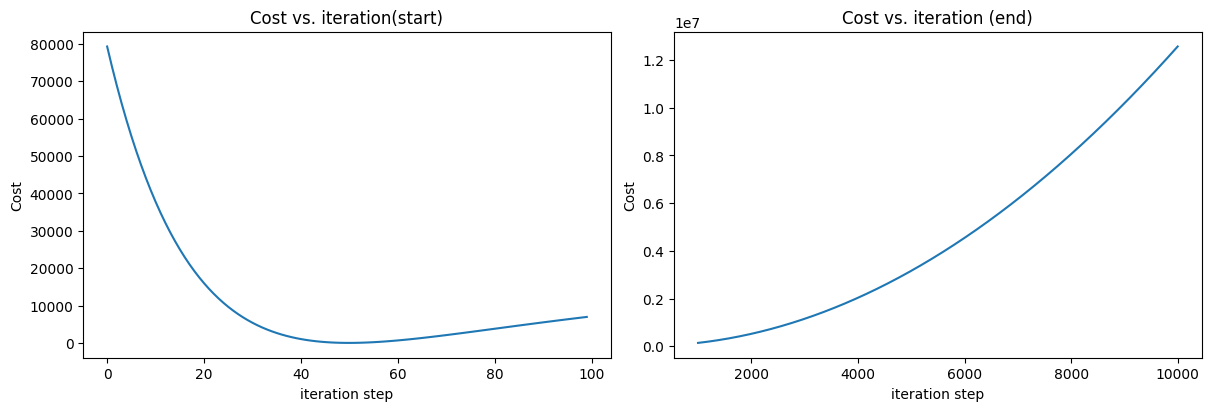

In [24]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()

In [25]:
print(f"1000 sqft house prediction {w_final*1.0 + b_final:0.1f} Thousand dollars")
print(f"1200 sqft house prediction {w_final*1.2 + b_final:0.1f} Thousand dollars")
print(f"2000 sqft house prediction {w_final*2.0 + b_final:0.1f} Thousand dollars")

1000 sqft house prediction -4560.0 Thousand dollars
1200 sqft house prediction -2516.0 Thousand dollars
2000 sqft house prediction 5660.0 Thousand dollars


In [ ]:
def plt_contour_wgrad(x, y, p_hist, ax, w_range=None, b_range=None, contours=None, resolution=0.5):
   
    # Set default ranges based on data if not provided
    if w_range is None:
        w_range = [-100, 600, 50]
    if b_range is None:
        b_range = [-100, 600, 50]
    if contours is None:
        contours = [1, 5, 10, 20, 50, 100, 200, 500, 1000]
    
    # Create grid for contour plot
    w = np.arange(w_range[0], w_range[1], w_range[2])
    b = np.arange(b_range[0], b_range[1], b_range[2])
    W, B = np.meshgrid(w, b)
    
    # Calculate cost for each point in the grid
    Z = np.zeros_like(W)
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            Z[i, j] = compute_cost(x, W[i, j], B[i, j], y)
    
    # Plot contour
    ax.contour(W, B, Z, levels=contours, cmap='viridis')
    
    # Plot the gradient descent path
    if p_hist:
        p_hist = np.array(p_hist)
        ax.plot(p_hist[:, 0], p_hist[:, 1], 'r.-', markersize=10, linewidth=2, label='Gradient descent path')
        ax.plot(p_hist[0, 0], p_hist[0, 1], 'go', markersize=10, label='Start')
        ax.plot(p_hist[-1, 0], p_hist[-1, 1], 'r*', markersize=15, label='End')
    
    ax.set_xlabel('w')
    ax.set_ylabel('b')
    ax.set_title('Contour plot with Gradient Descent')
    ax.legend()


In [29]:
def plt_divergence(p_hist, J_hist, x, y):
    """
    Plot to visualize divergence in gradient descent.
    Shows the path and cost history when learning rate is too high.
    """
    # Assuming p_hist is a list of [w, b] pairs
    p_hist = np.array(p_hist)
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot cost history
    ax1.plot(J_hist, 'r-', linewidth=2)
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Cost')
    ax1.set_title('Cost History (Divergence)')
    ax1.grid(True)
    
    # Plot contour with divergence path
    w = np.arange(-100, 600, 50)
    b = np.arange(-100, 600, 50)
    W, B = np.meshgrid(w, b)
    Z = np.zeros_like(W)
    
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            Z[i, j] = compute_cost(x, W[i, j], B[i, j], y)
    
    ax2.contour(W, B, Z, levels=[1, 5, 10, 20, 50, 100, 200, 500, 1000], cmap='viridis')
    
    # Plot the diverging path
    ax2.plot(p_hist[:, 0], p_hist[:, 1], 'r.-', markersize=10, linewidth=2, label='Diverging path')
    ax2.plot(p_hist[0, 0], p_hist[0, 1], 'go', markersize=10, label='Start')
    ax2.set_xlabel('w')
    ax2.set_ylabel('b')
    ax2.set_title('Contour Plot (with Divergence)')
    ax2.legend()
    
    return fig


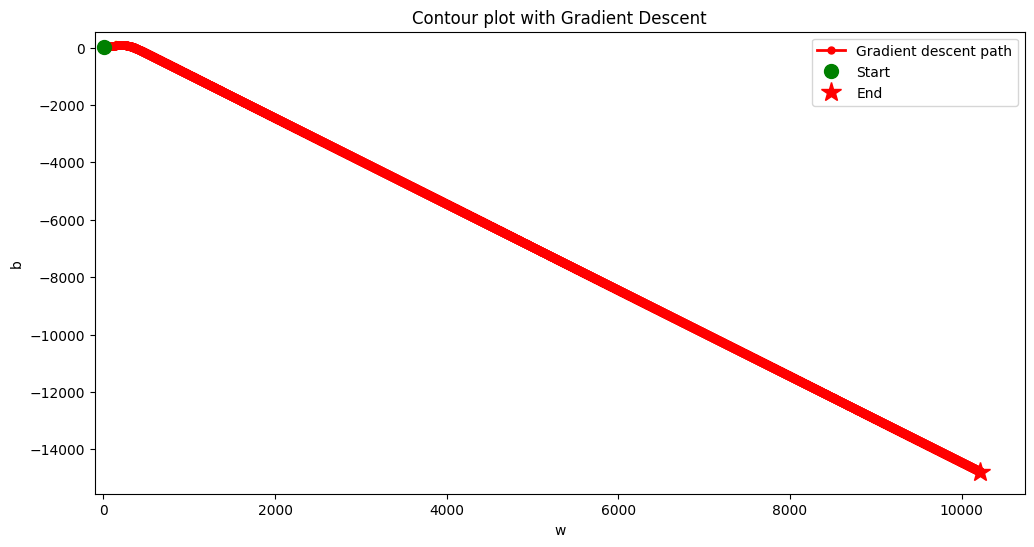

In [30]:
fig, ax = plt.subplots(1,1, figsize=(12, 6))
plt_contour_wgrad(x_train, y_train, p_hist, ax)

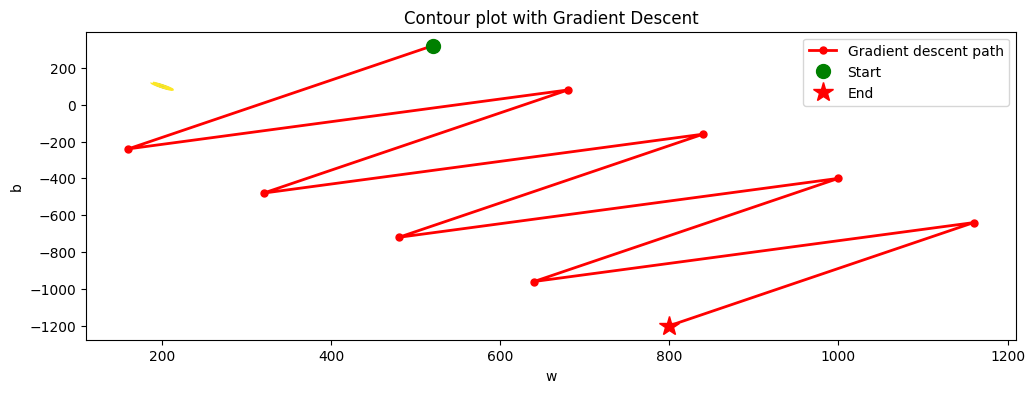

In [34]:
fig, ax = plt.subplots(1,1, figsize=(12, 4))
plt_contour_wgrad(x_train, y_train, p_hist, ax, w_range=[180, 220, 0.5], b_range=[80, 120, 0.5],
            contours=[1,5,10,20],resolution=0.5)

In [35]:
# initialize parameters
w_init = 0
b_init = 0
# set alpha to a large value
iterations = 10
tmp_alpha = 8.0e-1
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)

Iteration    0: Cost 2.58e+05  dj_dw: -6.500e+02, dj_db: -4.000e+02  w: 5.200e+02, b:3.20000e+02
Iteration    1: Cost 8.02e+04  dj_dw: 4.500e+02, dj_db: 7.000e+02  w: 1.600e+02, b:-2.40000e+02
Iteration    2: Cost 2.74e+05  dj_dw: -6.500e+02, dj_db: -4.000e+02  w: 6.800e+02, b:8.00000e+01
Iteration    3: Cost 8.18e+04  dj_dw: 4.500e+02, dj_db: 7.000e+02  w: 3.200e+02, b:-4.80000e+02
Iteration    4: Cost 2.96e+05  dj_dw: -6.500e+02, dj_db: -4.000e+02  w: 8.400e+02, b:-1.60000e+02
Iteration    5: Cost 8.98e+04  dj_dw: 4.500e+02, dj_db: 7.000e+02  w: 4.800e+02, b:-7.20000e+02
Iteration    6: Cost 3.25e+05  dj_dw: -6.500e+02, dj_db: -4.000e+02  w: 1.000e+03, b:-4.00000e+02
Iteration    7: Cost 1.04e+05  dj_dw: 4.500e+02, dj_db: 7.000e+02  w: 6.400e+02, b:-9.60000e+02
Iteration    8: Cost 3.60e+05  dj_dw: -6.500e+02, dj_db: -4.000e+02  w: 1.160e+03, b:-6.40000e+02
Iteration    9: Cost 1.25e+05  dj_dw: 4.500e+02, dj_db: 7.000e+02  w: 8.000e+02, b:-1.20000e+03


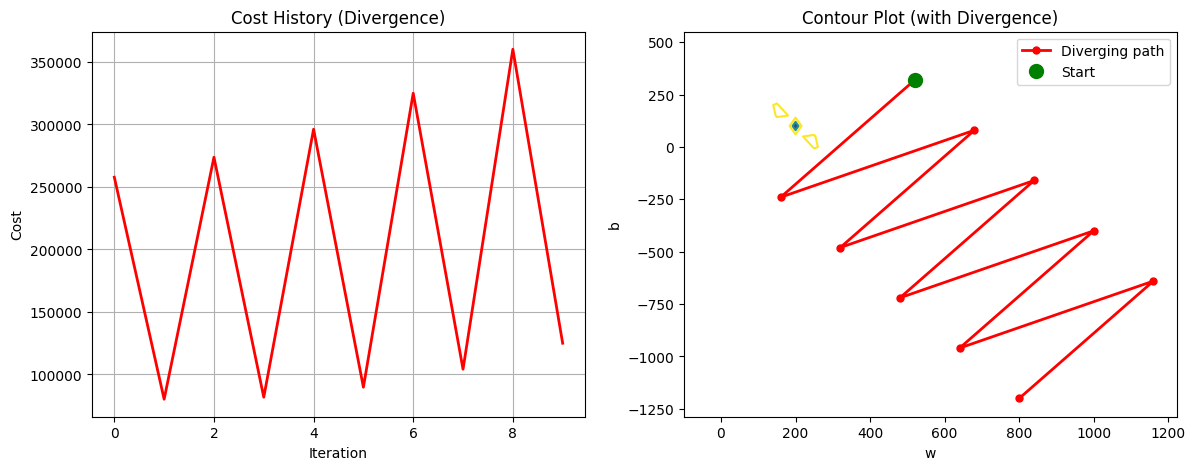

In [36]:
plt_divergence(p_hist, J_hist,x_train, y_train)
plt.show()